<a href="https://colab.research.google.com/github/shirin6767saleh/code-/blob/Fnew/comparisonfourierbasis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

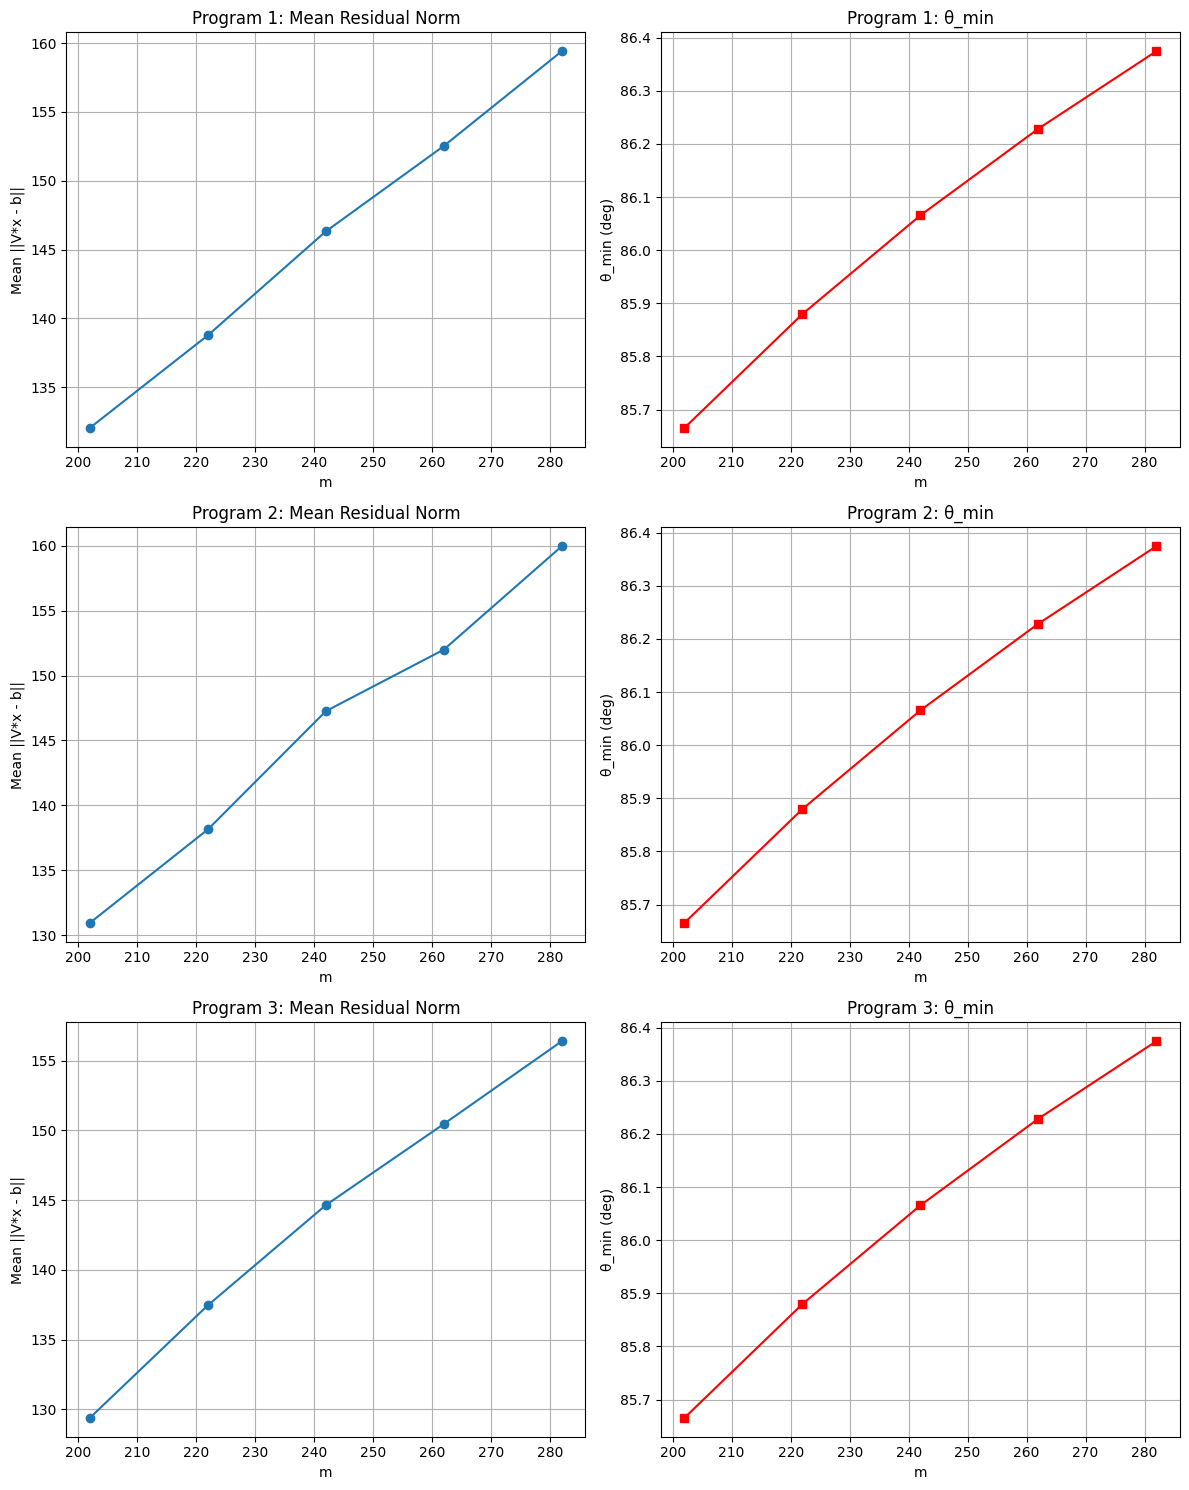

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ----------------------------
# Utility functions
# ----------------------------
def normalize_column(col):
    return col / np.linalg.norm(col)

def normalize_columns(matrix):
    return np.column_stack([normalize_column(matrix[:, i]) for i in range(matrix.shape[1])])

# ----------------------------
# m values
# ----------------------------
m_values = np.arange(202, 302, 20)

# ----------------------------
# Prepare figure
# ----------------------------
plt.figure(figsize=(12, 15))  # 3 rows, 2 columns

# ----------------------------
# Program 1
# ----------------------------
theta_min_vals_1 = []
residual_mean_vals_1 = []

for m in m_values:
    N = 4*m + 2
    theta = 0
    numVectors = N//10

    # G_theta
    w = np.exp(-2j * np.pi / N)
    k = np.arange(N).reshape(N,1)
    l = np.arange(N).reshape(1,N)
    G = (1/np.sqrt(N)) * w**((k - theta/2.0) * (l - theta/2.0))

    # Real/Imag
    C = np.real(G)
    S = np.imag(G)

    # P matrices (Chebyshev)
    C2 = C @ C
    S2 = S @ S
    P_1  = 0.25*(C2 + C)
    P_m1 = 0.25*(C2 - C)
    P_i  = 0.25*(S2 + S)
    P_mi = 0.25*(S2 - S)

    # Build V_F_cheby
    X = P_1[:, 0:m+1]
    Y = P_m1[:, 0:m+1]
    Z = P_i[:, 1:m+1]
    T = P_mi[:, 1:m+1]
    V_F_cheby = np.hstack([X, Y, Z, T])

    # Build diagonal matrix D
    size_X = X.shape[1]
    size_Y = Y.shape[1]
    size_Z = Z.shape[1]
    size_T = T.shape[1]
    diag_entries = np.hstack([
        np.ones(size_X),
        -np.ones(size_Y),
        1j*np.ones(size_Z),
        -1j*np.ones(size_T)
    ])
    D = np.diag(diag_entries)

    # Check G V = V D
    diff1 = G @ V_F_cheby - V_F_cheby @ D
    assert np.allclose(diff1, 0, atol=1e-6)

    # Residuals
    residual_norms = []
    for idx in range(numVectors):
        b = np.random.randn(N) * 10
        x = np.linalg.lstsq(V_F_cheby, b, rcond=None)[0]
        residual_norms.append(np.linalg.norm(V_F_cheby @ x - b))
    residual_mean_vals_1.append(np.mean(residual_norms))

    # Minimum angle
    Vn = normalize_columns(V_F_cheby)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:,i], Vn[:,j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals_1.append(np.degrees(min_angle))

# Plot program 1
plt.subplot(3,2,1)
plt.plot(m_values, residual_mean_vals_1, marker='o')
plt.title("Program 1: Mean Residual Norm")
plt.xlabel("m")
plt.ylabel("Mean ||V*x - b||")
plt.grid(True)

plt.subplot(3,2,2)
plt.plot(m_values, theta_min_vals_1, marker='s', color='red')
plt.title("Program 1: θ_min")
plt.xlabel("m")
plt.ylabel("θ_min (deg)")
plt.grid(True)

# ----------------------------
# Program 2
# ----------------------------
theta_min_vals_2 = []
residual_mean_vals_2 = []

for m in m_values:
    N = 4*m + 2
    theta = 0
    numVectors = 40

    w = np.exp(-2j * np.pi / N)
    k = np.arange(N).reshape(N,1)
    l = np.arange(N).reshape(1,N)
    G = (1/np.sqrt(N)) * w**((k - theta/2.0)*(l - theta/2.0))

    C = np.real(G)
    S = np.imag(G)

    P = 0.5*np.eye(N)
    P[0,0] = 1
    P[2*m+1, 2*m+1] = 1

    for k_idx in range(1, 2*m+1):
        P[k_idx, N-k_idx] = 0.5
        P[k_idx+2*m+1, N-k_idx-2*m-1] = -0.5

    Ph = P
    Ph_inv = np.linalg.inv(Ph)

    V_tmp = Ph @ C @ Ph_inv
    W_tmp = Ph @ S @ Ph_inv

    A = V_tmp[0:2*m+2, 0:2*m+2]
    B = W_tmp[2*m+2:N, 2*m+2:N]

    X_2 = (A + np.eye(2*m+2))[:, 0:m+1]
    Y_2 = (A - np.eye(2*m+2))[:, 0:m+1]
    Z_2 = (B + np.eye(2*m))[:, 0:m]
    T_2 = (B - np.eye(2*m))[:, 0:m]

    pad_rows_XY = N - X_2.shape[0]
    X_3 = Ph_inv @ np.vstack([X_2, np.zeros((pad_rows_XY, m+1))])
    Y_3 = Ph_inv @ np.vstack([Y_2, np.zeros((pad_rows_XY, m+1))])

    pad_rows_ZT = N - Z_2.shape[0]
    Z_3 = Ph_inv @ np.vstack([np.zeros((pad_rows_ZT, m)), Z_2])
    T_3 = Ph_inv @ np.vstack([np.zeros((pad_rows_ZT, m)), T_2])

    V_F_reim = np.hstack([X_3, Y_3, Z_3, T_3])

    size_X = X_3.shape[1]
    size_Y = Y_3.shape[1]
    size_Z = Z_3.shape[1]
    size_T = T_3.shape[1]

    diag_entries = np.hstack([
        np.ones(size_X),
        -np.ones(size_Y),
        1j*np.ones(size_Z),
        -1j*np.ones(size_T)
    ])
    D_3 = np.diag(diag_entries)

    diff1 = G @ V_F_reim - V_F_reim @ D_3
    assert np.allclose(diff1, 0, atol=1e-6)

    residual_norms = []
    for idx in range(numVectors):
        b = np.random.randn(N)*10
        x = np.linalg.lstsq(V_F_reim, b, rcond=None)[0]
        residual_norms.append(np.linalg.norm(V_F_reim @ x - b))
    residual_mean_vals_2.append(np.mean(residual_norms))

    Vn = normalize_columns(V_F_reim)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:,i], Vn[:,j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals_2.append(np.degrees(min_angle))

# Plot program 2
plt.subplot(3,2,3)
plt.plot(m_values, residual_mean_vals_2, marker='o')
plt.title("Program 2: Mean Residual Norm")
plt.xlabel("m")
plt.ylabel("Mean ||V*x - b||")
plt.grid(True)

plt.subplot(3,2,4)
plt.plot(m_values, theta_min_vals_2, marker='s', color='red')
plt.title("Program 2: θ_min")
plt.xlabel("m")
plt.ylabel("θ_min (deg)")
plt.grid(True)

# ----------------------------
# Program 3
# ----------------------------
theta_min_vals_3 = []
residual_mean_vals_3 = []

for m in m_values:
    N = 4*m + 2
    w = np.exp(-2j * np.pi / N)
    numVectors = 40
    d = np.ones(2*m+2)
    d[0] = 1/np.sqrt(2)
    d[2*m+1] = 1/np.sqrt(2)

    C = np.zeros((2*m+2, 2*m+2))
    for k_idx in range(2*m+2):
        for l_idx in range(2*m+2):
            C[k_idx,l_idx] = 1/np.sqrt(N) * d[k_idx]*d[l_idx]*np.cos(k_idx*l_idx*2*np.pi/N)

    S = np.zeros((2*m, 2*m))
    for k_idx in range(2*m):
        for l_idx in range(2*m):
            S[k_idx,l_idx] = 1/np.sqrt(N) * np.sin((k_idx+1)*(l_idx+1)*2*np.pi/N)

    X = C + 0.5*np.eye(2*m+2)
    Y = C - 0.5*np.eye(2*m+2)
    Z = S + 0.5*np.eye(2*m)
    T = S - 0.5*np.eye(2*m)

    F = np.zeros((N,N), dtype=complex)
    for k_idx in range(N):
        for l_idx in range(N):
            F[k_idx,l_idx] = 1/np.sqrt(N) * w**(k_idx*l_idx)

    J = np.fliplr(np.eye(2*m))

    X1 = X[:, :m+1]
    Y1 = Y[:, :m+1]
    Z1 = Z[:, :m]
    T1 = T[:, :m]

    X0 = X1[1:2*m+1, :]
    Y0 = Y1[1:2*m+1, :]

    X2 = np.vstack([np.sqrt(2)*X1[0,:], X0, np.sqrt(2)*X1[2*m+1,:], J @ X0])
    Y2 = np.vstack([np.sqrt(2)*Y1[0,:], Y0, np.sqrt(2)*Y1[2*m+1,:], J @ Y0])
    Z2 = np.vstack([np.zeros((1,m)), Z1, np.zeros((1,m)), -J @ Z1])
    T2 = np.vstack([np.zeros((1,m)), T1, np.zeros((1,m)), -J @ T1])

    V_kernelmatrix = np.hstack([X2, Y2, T2, Z2])

    D_2 = np.zeros((N,N), dtype=complex)
    for k_idx in range(m+1):
        D_2[k_idx,k_idx] = 1
        D_2[m+1+k_idx, m+1+k_idx] = -1
    for k_idx in range(m):
        D_2[2*m+2+k_idx, 2*m+2+k_idx] = 1j
        D_2[3*m+2+k_idx, 3*m+2+k_idx] = -1j

    diff = F @ V_kernelmatrix - V_kernelmatrix @ D_2
    assert np.allclose(diff, 0, atol=1e-6)

    residual_norms = []
    for idx in range(numVectors):
        b = np.random.randn(N)*10
        x = np.linalg.lstsq(V_kernelmatrix, b, rcond=None)[0]
        residual_norms.append(np.linalg.norm(V_kernelmatrix @ x - b))
    residual_mean_vals_3.append(np.mean(residual_norms))

    Vn = normalize_columns(V_kernelmatrix)
    min_angle = np.pi
    for i in range(Vn.shape[1]):
        for j in range(i+1, Vn.shape[1]):
            inner = np.clip(np.dot(Vn[:,i], Vn[:,j]), -1.0, 1.0)
            angle = np.arccos(inner)
            if angle < min_angle:
                min_angle = angle
    theta_min_vals_3.append(np.degrees(min_angle))

# Plot program 3
plt.subplot(3,2,5)
plt.plot(m_values, residual_mean_vals_3, marker='o')
plt.title("Program 3: Mean Residual Norm")
plt.xlabel("m")
plt.ylabel("Mean ||V*x - b||")
plt.grid(True)

plt.subplot(3,2,6)
plt.plot(m_values, theta_min_vals_3, marker='s', color='red')
plt.title("Program 3: θ_min")
plt.xlabel("m")
plt.ylabel("θ_min (deg)")
plt.grid(True)

plt.tight_layout()
plt.show()
